In [ ]:
!apt-get update
!apt-get install -y libglu1-mesa
!pip install gmsh numpy

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:2 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:10 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,295 kB]
Get:11 http://security.ubuntu.com/ubuntu jammy-security/multiverse amd64 Packages [77.8 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,955 kB]
Get:13 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [95.6 kB

In [ ]:
# ============================================================
# CELL A — Environment + Downloads
# ============================================================

import subprocess, sys
for pkg in ["nibabel", "h5py" , "open3d"]:
    try: __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
        import subprocess, sys


import os, json, random, h5py
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import nibabel as nib
from collections import Counter
from huggingface_hub import hf_hub_download

# ── Config ───────────────────────────────────────────────────
HF_REPO         = "hourouu/data"          # slices, index
HF_SOURCE_REPO  = "hourouu/LIDC_IDRI_NORMALIZED"   # original NIfTI volumes
MODEL2_REPO     = "hourouu/model4"                  # split_indices.json, best.pth
SPLIT_FILE_LOCAL= "/content/split_indices.json"
H5_LOCAL        = "/content/slices.h5"
INDEX_LOCAL     = "/content/slice_index.json"
CKPT_LOCAL      = "/content/best.pth"
SAVE_DIR        = "/content/reconstruction"
IMAGE_SIZE      = 128
MIN_REAL_SLICES = 200
THRESHOLD       = 0.5
DEVICE          = torch.device("cuda" if torch.cuda.is_available() else "cpu")

os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Device: {DEVICE}")

# ── 1. Download slice_index.json ─────────────────────────────
print("\n[1/4] Downloading slice_index.json...", end="", flush=True)
hf_hub_download(repo_id=HF_REPO, filename="slice_index.json",
                repo_type="dataset", local_dir="/content", force_download=True)
print(" done.")

# ── 1b. Download split_indices.json (authoritative split from training) ───────
print("[2/4] Downloading split_indices.json...", end="", flush=True)
hf_hub_download(repo_id=MODEL2_REPO, filename="split_indices.json",
                repo_type="dataset", local_dir="/content", force_download=True)
print(" done.")

# ── 2. Download slices.h5 ────────────────────────────────────
if os.path.exists(H5_LOCAL):
    print(f"[3/4] slices.h5 already on disk "
          f"({os.path.getsize(H5_LOCAL)/1e9:.2f} GB) — skipping.")
else:
    print("[3/4] Downloading slices.h5...", flush=True)
    hf_hub_download(repo_id=HF_REPO, filename="slices.h5",
                    repo_type="dataset", local_dir="/content", force_download=False)
    print(f"  done ({os.path.getsize(H5_LOCAL)/1e9:.2f} GB).")

# ── 3. Download best.pth ─────────────────────────────────────
print("[4/4] Downloading best.pth...", end="", flush=True)
hf_hub_download(repo_id=MODEL2_REPO, filename="best.pth",
                repo_type="dataset", local_dir="/content", force_download=True)
print(" done.")

print("\n[Cell A OK] — all assets on disk.")


Device: cpu

[1/4] Downloading slice_index.json...

slice_index.json: 0.00B [00:00, ?B/s]

 done.
[2/4] Downloading split_indices.json...

split_indices.json: 0.00B [00:00, ?B/s]

 done.
[3/4] Downloading slices.h5...


slices.h5:   0%|          | 0.00/5.74G [00:00<?, ?B/s]

  done (5.74 GB).
[4/4] Downloading best.pth...

best.pth:   0%|          | 0.00/93.2M [00:00<?, ?B/s]

 done.

[Cell A OK] — all assets on disk.


In [ ]:
# ============================================================
# CELL B — Model Definition + Load Weights
# ============================================================

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, 3, padding=1, bias=False),
            nn.InstanceNorm2d(out_ch, affine=True), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.InstanceNorm2d(out_ch, affine=True), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)

class UNetV2(nn.Module):
    def __init__(self, in_ch=1, base_ch=32):
        super().__init__()
        b = base_ch
        self.enc1 = ConvBlock(in_ch, b);   self.enc2 = ConvBlock(b,   b*2)
        self.enc3 = ConvBlock(b*2,  b*4);  self.enc4 = ConvBlock(b*4, b*8)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = ConvBlock(b*8, b*16)
        self.up4  = nn.ConvTranspose2d(b*16, b*8, 2, stride=2)
        self.dec4 = ConvBlock(b*16, b*8)
        self.up3  = nn.ConvTranspose2d(b*8,  b*4, 2, stride=2)
        self.dec3 = ConvBlock(b*8,  b*4)
        self.up2  = nn.ConvTranspose2d(b*4,  b*2, 2, stride=2)
        self.dec2 = ConvBlock(b*4,  b*2)
        self.up1  = nn.ConvTranspose2d(b*2,  b,   2, stride=2)
        self.dec1 = ConvBlock(b*2,  b)
        self.out  = nn.Conv2d(b, 1, 1)

    def forward(self, x):
        s1 = self.enc1(x);               s2 = self.enc2(self.pool(s1))
        s3 = self.enc3(self.pool(s2));   s4 = self.enc4(self.pool(s3))
        b  = self.bottleneck(self.pool(s4))
        d4 = self.dec4(torch.cat([self.up4(b),  s4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), s3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), s2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), s1], dim=1))
        return self.out(d1)

model = UNetV2().to(DEVICE)
ckpt  = torch.load(CKPT_LOCAL, map_location=DEVICE)
model.load_state_dict(ckpt["model_state"])
model.eval()

print(f"UNetV2 loaded — epoch {ckpt.get('epoch','?')} | "
      f"best Dice {ckpt.get('best_dice', 0):.4f}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
print("[Cell B OK]")

UNetV2 loaded — epoch 7 | best Dice 0.9044
Parameters: 7,762,465
[Cell B OK]


In [ ]:
# ============================================================
# CELL C — Direct patient loading
# ============================================================

chosen_pid = "LIDC-IDRI-0045" # 0370 0164, 0072, and 0469 , 0082 , 0045,

local_path = hf_hub_download(
    repo_id=HF_SOURCE_REPO,
    filename=f"images/{chosen_pid}_img.nii.gz",
    repo_type="dataset",
    force_download=False
)

nii = nib.load(local_path)
affine = nii.affine
voxel_spacing = nii.header.get_zooms()
volume = nii.get_fdata()

print(f"Patient   : {chosen_pid}")
print(f"Path      : {local_path}")
print(f"Shape     : {volume.shape}")
print(f"Spacing   : {voxel_spacing[0]:.2f} x {voxel_spacing[1]:.2f} x {voxel_spacing[2]:.2f} mm")
print("Ready — run Cell D.")


images/LIDC-IDRI-0045_img.nii.gz:   0%|          | 0.00/47.9M [00:00<?, ?B/s]

Patient   : LIDC-IDRI-0045
Path      : /root/.cache/huggingface/hub/datasets--hourouu--LIDC_IDRI_NORMALIZED/snapshots/8e1a935c37574afd37081f38c2c63ea3d1a111e8/images/LIDC-IDRI-0045_img.nii.gz
Shape     : (88, 340, 1280)
Spacing   : 1.00 x 1.00 x 1.00 mm
Ready — run Cell D.


Running inference on 1280 slices...
  50/88
Inference done. Logit tensor: torch.Size([88, 1, 128, 128])

Upsampling 128x128 → 88x340...
Done. Lung slices: 73 / 88


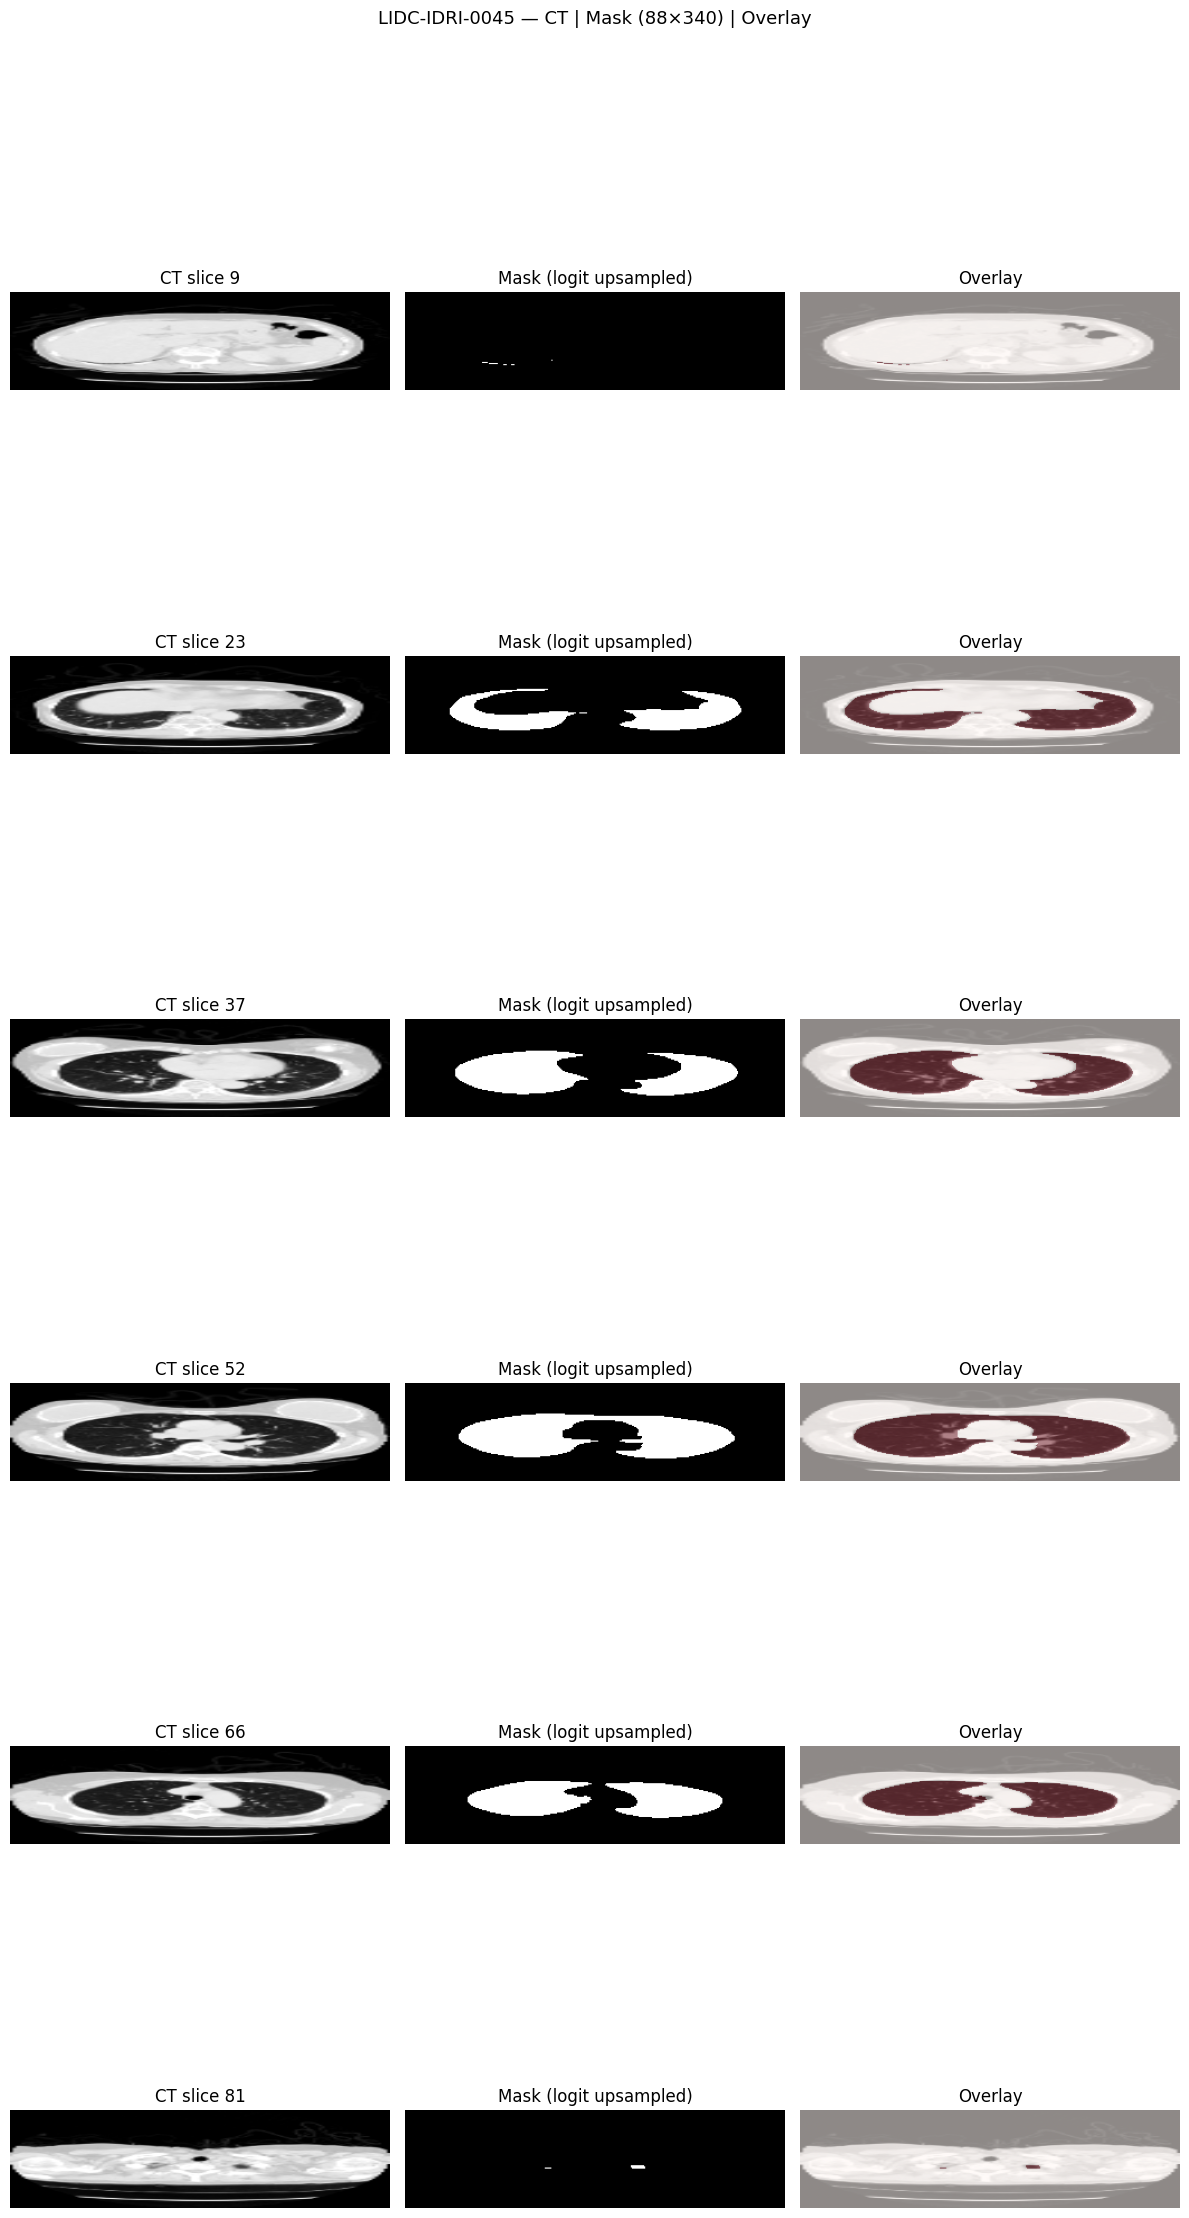

Visualization saved → /content/reconstruction/LIDC-IDRI-0045_preview.png

Saved to /content/reconstruction/
  CT   : LIDC-IDRI-0045_ct.nii.gz  shape=(88, 88, 340)
  Mask : LIDC-IDRI-0045_mask.nii.gz shape=(88, 88, 340)
  Voxel spacing : 1.00 x 1.00 x 1.00 mm
  Affine embedded — ready for marching cubes.
[Cell D OK]


In [ ]:
# ============================================================
# CELL D — Inference + Upsample + Visualize + Save YOUSRA
# ============================================================

import matplotlib.pyplot as plt

assert chosen_pid is not None, "Run Cell C first."

N_VIS    = 6
BATCH    = 16
native_H = volume.shape[0]
native_W = volume.shape[1]
n_slices = volume.shape[2]

# ── Preprocess — mirrors training pipeline exactly ───────────
# LIDC_IDRI_NORMALIZED stores values already in [0,1].
# Safety clamp included — if values are outside range after
# get_fdata(), check the source repo normalization and adjust.
def preprocess_slice(slice_2d):
    s = np.clip(slice_2d.astype(np.float32), 0.0, 1.0)
    t = torch.from_numpy(s).unsqueeze(0).unsqueeze(0)  # (1,1,H,W)
    return F.interpolate(t, size=(IMAGE_SIZE, IMAGE_SIZE),
                         mode="bilinear", align_corners=False)

# ── Inference — store raw logits, never threshold here ───────
print(f"Running inference on {n_slices} slices...", flush=True)
logits_128 = []
slices_128 = []

with torch.no_grad():
    n_slices = volume.shape[0]
    for z in range(n_slices):
        inp = preprocess_slice(volume[z, :, :]).to(DEVICE)
        logit = model(inp)                      # (1,1,128,128)
        logits_128.append(logit.cpu())
        slices_128.append(inp.cpu())
        if (z + 1) % 50 == 0:
            print(f"  {z+1}/{n_slices}", flush=True)

logits_128 = torch.cat(logits_128, dim=0)      # (Z,1,128,128)
slices_128 = torch.cat(slices_128, dim=0)      # (Z,1,128,128)
print(f"Inference done. Logit tensor: {logits_128.shape}")


# ── Upsample logit → native res, threshold once ──────────────

print(f"\nUpsampling 128x128 → {native_H}x{native_W}...", flush=True)
masks_native = []
cts_native   = []

for start in range(0, n_slices, BATCH):
    end = min(start + BATCH, n_slices)

    logit_up = F.interpolate(
        logits_128[start:end],
        size=(native_H, native_W),
        mode="bilinear", align_corners=False)

    masks_native.append((torch.sigmoid(logit_up) > THRESHOLD).float())
    cts_native.append(F.interpolate(
        slices_128[start:end],
        size=(native_H, native_W),
        mode="bilinear", align_corners=False))

masks_native = torch.cat(masks_native, dim=0)  # (Z,1,H,W)
cts_native   = torch.cat(cts_native,   dim=0)  # (Z,1,H,W)

n_lung = int((masks_native.sum(dim=(1,2,3)) > 0).sum().item())
print(f"Done. Lung slices: {n_lung} / {n_slices}")

# ── Visualize N evenly-spaced lung slices ────────────────────
lung_ids = [z for z in range(n_slices)
            if masks_native[z, 0].sum().item() > 0]
vis_ids  = [lung_ids[i] for i in
            np.linspace(0, len(lung_ids)-1, N_VIS, dtype=int)]

fig, axes = plt.subplots(N_VIS, 3, figsize=(12, 4*N_VIS))
fig.suptitle(
    f"{chosen_pid} — CT | Mask ({native_H}×{native_W}) | Overlay",
    fontsize=13, y=1.01)

for row, z in enumerate(vis_ids):
    ct   = cts_native[z, 0].numpy()
    mask = masks_native[z, 0].numpy()

    axes[row, 0].imshow(ct,   cmap="gray")
    axes[row, 0].set_title(f"CT slice {z}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(mask, cmap="gray")
    axes[row, 1].set_title("Mask (logit upsampled)")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(ct,   cmap="gray",  alpha=0.8)
    axes[row, 2].imshow(mask, cmap="Reds",  alpha=0.45, vmin=0, vmax=1)
    axes[row, 2].set_title("Overlay")
    axes[row, 2].axis("off")

plt.tight_layout()
vis_path = os.path.join(SAVE_DIR, f"{chosen_pid}_preview.png")
plt.savefig(vis_path, dpi=130, bbox_inches="tight")
plt.show()
print(f"Visualization saved → {vis_path}")

# ── Save CT + mask as NIfTI with original affine ─────────────
ct_vol   = cts_native[:, 0, :, :].numpy()    # (Z, H, W)
mask_vol = masks_native[:, 0, :, :].numpy()  # (Z, H, W)

ct_path   = os.path.join(SAVE_DIR, f"{chosen_pid}_ct.nii.gz")
mask_path = os.path.join(SAVE_DIR, f"{chosen_pid}_mask.nii.gz")

nib.save(nib.Nifti1Image(ct_vol.astype(np.float32),   affine), ct_path)
nib.save(nib.Nifti1Image(mask_vol.astype(np.float32), affine), mask_path)

print(f"\nSaved to {SAVE_DIR}/")
print(f"  CT   : {os.path.basename(ct_path)}  shape={ct_vol.shape}")
print(f"  Mask : {os.path.basename(mask_path)} shape={mask_vol.shape}")
print(f"  Voxel spacing : {voxel_spacing[0]:.2f} x "
      f"{voxel_spacing[1]:.2f} x {voxel_spacing[2]:.2f} mm")
print(f"  Affine embedded — ready for marching cubes.")
print("[Cell D OK]")

## RECONSTRUCTION : TRACHEE -

In [ ]:
# ============================================================
# CELL — Reconstruction 3D avec suppression trachée (Cell F)
# ============================================================
import subprocess, sys
for pkg in ["scikit-image", "trimesh", "nibabel", "scipy"]:
    try: __import__(pkg.replace("-", "_").split(".")[0])
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

import numpy as np
import nibabel as nib
import os
from scipy import ndimage
from skimage.morphology import label, ball
from skimage.measure import regionprops
from skimage import measure
import plotly.graph_objects as go
import trimesh

# ── Config ───────────────────────────────────────────────────
SAVE_DIR          = "/content/reconstruction"
PATIENT_ID        = chosen_pid
MASK_PATH         = os.path.join(SAVE_DIR, f"{PATIENT_ID}_mask.nii.gz")
MESH_OUT_PATH     = os.path.join(SAVE_DIR, f"{PATIENT_ID}_lung_mesh.stl")
TAUBIN_LAMBDA     = 0.5
TAUBIN_MU         = -0.53
TAUBIN_ITERATIONS = 20

# Paramètres remove_trachea (Cell F)
TRACHEA_PARAMS = dict(
    min_trachea_area = 500,
    center_fraction  = 0.25,
    trachea_radius   = 17,
    erosion_radius   = 4,
    erosion_iterations = None,
    keep_n           = 2,
    size_pct         = 0.03,
)

# ── Fonction remove_trachea (Cell F) ─────────────────────────
def remove_trachea(volume: np.ndarray, **kwargs) -> np.ndarray:
    vol_bool = volume.astype(bool)
    Z, H, W  = volume.shape
    center_x = W // 2

    # ── Étape 1 : Identification coupe par coupe ──────────────
    min_area    = kwargs.get('min_trachea_area', 80)
    center_frac = kwargs.get('center_fraction', 0.25)

    mask_step1        = vol_bool.copy()
    trachea_centroids = []

    for z in range(Z):
        slice_mask    = vol_bool[z]
        labeled_slice = label(slice_mask)
        props         = regionprops(labeled_slice)

        for region in props:
            cy, cx = region.centroid
            if (region.area < min_area and
                    abs(cx - center_x) < (W / 2) * center_frac):
                mask_step1[z][labeled_slice == region.label] = 0
                trachea_centroids.append((z, cy, cx))

    print(f"  [Étape 1] Régions supprimées : {len(trachea_centroids)}")

    # ── Étape 2 : Régression linéaire SANS extrapolation ──────
    mask_step2 = mask_step1.copy()

    if len(trachea_centroids) >= 3:
        centroids_arr = np.array(trachea_centroids)
        zs  = centroids_arr[:, 0]
        cys = centroids_arr[:, 1]
        cxs = centroids_arr[:, 2]

        poly_cx = np.polyfit(zs, cxs, deg=1)
        poly_cy = np.polyfit(zs, cys, deg=1)

        trachea_cx_fn = np.poly1d(poly_cx)
        trachea_cy_fn = np.poly1d(poly_cy)

        z_min = int(zs.min())
        z_max = int(zs.max()) + 1

        print(f"  [Étape 2] Plage Z trachée : {z_min} → {z_max}")

        # ── Étape 3 : Suppression radiale le long de la trajectoire
        trachea_radius = kwargs.get('trachea_radius', 17)
        yy, xx         = np.ogrid[:H, :W]

        swept = 0
        for z in range(max(0, z_min), min(Z, z_max)):
            pred_cx = trachea_cx_fn(z)
            pred_cy = trachea_cy_fn(z)
            dist    = np.sqrt((xx - pred_cx)**2 + (yy - pred_cy)**2)
            removed = int((mask_step2[z] & (dist <= trachea_radius)).sum())
            if removed > 0:
                mask_step2[z][dist <= trachea_radius] = 0
                swept += 1

        print(f"  [Étape 3] Coupes balayées  : {swept} | "
              f"radius={trachea_radius}px")
    else:
        print("  [Étape 2/3] Pas assez de centroïdes — sweep ignoré.")

    # ── Étape 4 : Séparation morphologique des lobes ──────────
    erosion_radius = kwargs.get('erosion_radius', 3)
    volume_voxels  = int(mask_step2.sum())
    n_iter = kwargs.get('erosion_iterations') or int(
        np.clip(volume_voxels // 20_000, 1, 2)
    )

    struct_sphere = ball(erosion_radius).astype(bool)

    eroded          = ndimage.binary_erosion(
        mask_step2, structure=struct_sphere, iterations=n_iter
    )
    labeled_vol, n_comp = ndimage.label(eroded.astype(np.uint8))

    print(f"  [Étape 4] Composantes après érosion : {n_comp} "
          f"(radius={erosion_radius}, iter={n_iter})")

    if n_comp == 0:
        print("  AVERTISSEMENT : aucune composante trouvée — "
              "masque original retourné.")
        return volume.astype(np.uint8)

    comp_sizes  = sorted(
        [{"id": cid, "size": int((labeled_vol == cid).sum())}
         for cid in range(1, n_comp + 1)],
        key=lambda x: x["size"], reverse=True
    )
    largest_size = comp_sizes[0]["size"]
    keep_n       = kwargs.get('keep_n',    2)
    size_pct     = kwargs.get('size_pct',  0.08)

    kept = [c for c in comp_sizes[:keep_n]
            if c["size"] >= largest_size * size_pct]

    print(f"  [Étape 4] Lobes conservés : {len(kept)}")
    for c in kept:
        print(f"    id={c['id']}  →  {c['size']:,} voxels")

    mask_eroded = np.zeros_like(eroded, dtype=bool)
    for c in kept:
        mask_eroded |= (labeled_vol == c["id"])

    mask_dilated = ndimage.binary_dilation(
        mask_eroded, structure=struct_sphere, iterations=n_iter
    )

    result = (mask_dilated & vol_bool).astype(np.uint8)
    return result


## METRIQUES

In [ ]:
# ════════════════════════════════════════════════════════════════════
# HELPER — Métriques mesh + sauvegarde par étape
# ════════════════════════════════════════════════════════════════════


def compute_mesh_metrics(tmesh, label="mesh", file_path=None):
    """Métriques surfaciques uniquement — pas de quality ratio."""
    n_verts  = len(tmesh.vertices)
    n_faces  = len(tmesh.faces)
    is_wt    = bool(tmesh.is_watertight)

    vol_mm3  = round(float(abs(tmesh.volume)), 3) if is_wt else None
    vol_mL = round(vol_mm3 / 1000.0, 3) if vol_mm3 is not None else None
    surf_cm2 = round(float(tmesh.area) / 100.0, 3)

    file_size_MB = (round(os.path.getsize(file_path) / 1e6, 3)
                    if file_path and os.path.exists(file_path) else None)

    return {
        "etape"             : label,
        "n_vertices"        : n_verts,
        "n_faces"           : n_faces,
        "watertight"        : is_wt,
        "volume_mm3"        : vol_mm3,
        "volume_mL"         : vol_mL,
        "surface_cm2"       : surf_cm2,
        "fichier_stl"       : os.path.basename(file_path) if file_path else None,
        "taille_fichier_MB" : file_size_MB,
    }


def save_stage(tmesh, path, label, all_metrics_dict):
    """Exporte le mesh en STL, calcule les métriques et les accumule."""
    tmesh.export(path)
    m = compute_mesh_metrics(tmesh, label=label, file_path=path)
    all_metrics_dict[label] = m

    print(f"\n  ── [{label}]  →  {os.path.basename(path)}")
    print(f"     Vertices   : {m['n_vertices']:>10,}  |  Faces : {m['n_faces']:>10,}")
    print(f"     Watertight : {m['watertight']}")
    if m['volume_mL'] is not None:
        print(f"     Volume     : {m['volume_mL']} mL  ({m['volume_mm3']:.0f} mm³)")
    if m['surface_cm2'] is not None:
        print(f"     Surface    : {m['surface_cm2']} cm²")
    if m['taille_fichier_MB'] is not None:
        print(f"     Fichier    : {m['taille_fichier_MB']} MB")
    return m

print("Helpers rechargés — vous pouvez relancer la reconstruction.")


# Dictionnaire global qui accumule toutes les métriques par étape
ALL_STAGE_METRICS = {}

# ── 1. Chargement du masque ───────────────────────────────────
print("Chargement du masque...", flush=True)
nii           = nib.load(MASK_PATH)
mask_vol      = nii.get_fdata().astype(np.uint8)

print(f"  Shape         : {mask_vol.shape}")
print(f"  Voxel spacing : {voxel_spacing[0]:.2f} x "
      f"{voxel_spacing[1]:.2f} x {voxel_spacing[2]:.2f} mm")

# ── 2. Suppression de la trachée (Cell F) ────────────────────
print("\nSuppression de la trachée (4 étapes)...", flush=True)
mask_clean = remove_trachea(mask_vol, **TRACHEA_PARAMS)
print(f"  Voxels restants : {int(mask_clean.sum()):,}")

# ─── ÉTAPE INTERMÉDIAIRE : Marching Cubes sur masque AVEC trachée ──
print("\n  [Sauvegarde intermédiaire] MC sur masque BRUT (avec trachée)...", flush=True)

# === AJOUT : Padding de 2 voxels ===
mask_vol_padded = np.pad(mask_vol.astype(np.float32), pad_width=2, mode='constant', constant_values=0)
mask_raw_mc = np.transpose(mask_vol_padded, (1, 2, 0))
_spacing_mc = (float(voxel_spacing[1]), float(voxel_spacing[2]), float(voxel_spacing[0]))

_verts_raw, _faces_raw, _normals_raw, _ = measure.marching_cubes(
    mask_raw_mc,
    level=0.5,
    spacing=_spacing_mc,
    method="lewiner",
    allow_degenerate=False
)

_mesh_raw_with_trachea = trimesh.Trimesh(vertices=_verts_raw, faces=_faces_raw,
                                          vertex_normals=_normals_raw)

MESH_RAW_WITH_TRACHEA_PATH = os.path.join(SAVE_DIR, f"{PATIENT_ID}_01_mesh_brut_avec_trachee.stl")
save_stage(_mesh_raw_with_trachea, MESH_RAW_WITH_TRACHEA_PATH,
           "01_mesh_brut_avec_trachee", ALL_STAGE_METRICS)

# ── 3. Marching Cubes sur masque SANS trachée ─────────────────
print("\nMarching Cubes (sans trachée)...", flush=True)

# === AJOUT : Padding de 2 voxels ===
mask_clean_padded = np.pad(mask_clean.astype(np.float32), pad_width=2, mode='constant', constant_values=0)
mask_mc = np.transpose(mask_clean_padded, (1, 2, 0))

spacing_mc = (float(voxel_spacing[1]),
              float(voxel_spacing[2]),
              float(voxel_spacing[0]))

verts, faces, normals, _ = measure.marching_cubes(
    mask_mc,
    level=0.5,
    spacing=spacing_mc,
    method="lewiner",
    allow_degenerate=False
)

print(f"  Vertices : {len(verts):,}")
print(f"  Faces    : {len(faces):,}")

# ─── SAUVEGARDE ÉTAPE 2 : mesh brut sans trachée (avant lissage) ─
mesh_raw = trimesh.Trimesh(vertices=verts.copy(), faces=faces.copy(),
                            vertex_normals=normals.copy())
MESH_RAW_PATH = os.path.join(SAVE_DIR, f"{PATIENT_ID}_02_mesh_brut_sans_trachee.stl")
save_stage(mesh_raw, MESH_RAW_PATH, "02_mesh_brut_sans_trachee", ALL_STAGE_METRICS)

# ── 4. Lissage Taubin ─────────────────────────────────────────
print("\nLissage Taubin...", flush=True)
mesh = trimesh.Trimesh(vertices=verts, faces=faces,
                       vertex_normals=normals)
trimesh.smoothing.filter_taubin(
    mesh,
    lamb=TAUBIN_LAMBDA,
    nu=TAUBIN_MU,
    iterations=TAUBIN_ITERATIONS
)
print(f"  Vertices : {len(mesh.vertices):,}")
print(f"  Faces    : {len(mesh.faces):,}")
print(f"  Watertight : {mesh.is_watertight}")

# ─── SAUVEGARDE ÉTAPE 3 : mesh lissé complet ─────────────────
MESH_SMOOTHED_PATH = os.path.join(SAVE_DIR, f"{PATIENT_ID}_03_mesh_lisse_taubin.stl")
save_stage(mesh, MESH_SMOOTHED_PATH, "03_mesh_lisse_taubin", ALL_STAGE_METRICS)

# ── 5. Export principal (compatibilité aval) ──────────────────
mesh.export(MESH_OUT_PATH)
print(f"\nMesh principal sauvegardé → {MESH_OUT_PATH}")

fig = go.Figure(data=[
    go.Mesh3d(
        x=mesh.vertices[:, 0],
        y=mesh.vertices[:, 1],
        z=mesh.vertices[:, 2],
        i=mesh.faces[:, 0],
        j=mesh.faces[:, 1],
        k=mesh.faces[:, 2],
        color="lightcoral",
        opacity=0.85,
        lighting=dict(ambient=0.4, diffuse=0.8, specular=0.2),
    )
])
fig.update_layout(
    title=f"Reconstruction pulmonaire — {PATIENT_ID}",
    scene=dict(
        xaxis_title="X (mm)",
        yaxis_title="Y (mm)",
        zaxis_title="Z (mm)",
        aspectmode="data"
    ),
    width=900, height=700
)
fig.show()
print("[Cell OK]")


Helpers rechargés — vous pouvez relancer la reconstruction.
Chargement du masque...
  Shape         : (88, 88, 340)
  Voxel spacing : 1.00 x 1.00 x 1.00 mm

Suppression de la trachée (4 étapes)...
  [Étape 1] Régions supprimées : 23
  [Étape 2] Plage Z trachée : 9 → 82
  [Étape 3] Coupes balayées  : 58 | radius=17px
  [Étape 4] Composantes après érosion : 5 (radius=4, iter=2)
  [Étape 4] Lobes conservés : 2
    id=3  →  43,182 voxels
    id=2  →  25,686 voxels
  Voxels restants : 234,736

  [Sauvegarde intermédiaire] MC sur masque BRUT (avec trachée)...

  ── [01_mesh_brut_avec_trachee]  →  LIDC-IDRI-0045_01_mesh_brut_avec_trachee.stl
     Vertices   :     65,340  |  Faces :    130,728
     Watertight : True
     Volume     : 294.619 mL  (294619 mm³)
     Surface    : 514.831 cm²
     Fichier    : 6.536 MB

Marching Cubes (sans trachée)...
  Vertices : 40,676
  Faces    : 81,344

  ── [02_mesh_brut_sans_trachee]  →  LIDC-IDRI-0045_02_mesh_brut_sans_trachee.stl
     Vertices   :     40,

[Cell OK]


## REDUCTION QEM

In [ ]:
# ============================================================
# CELL F — Réduction polygonale + Métriques + JSON pipeline
# ============================================================

import time
import json
import numpy as np
import trimesh
import open3d as o3d
from scipy.spatial import cKDTree
import os

TARGET_FACES       = 60_000
REDUCTION_STRATEGY = "quadric"
HAUSDORFF_SAMPLES  = 10_000

MESH_REDUCED_PATH = os.path.join(SAVE_DIR, f"{PATIENT_ID}_lung_mesh_reduced.stl")

assert "mesh" in globals() and mesh is not None, "Run the mesh generation cell first."

# ════════════════════════════════════════════════════════════════════
# SECTION 2 — Réduction polygonale (QEM)
# ════════════════════════════════════════════════════════════════════
print("═" * 60)
print("  SECTION 2 — Réduction polygonale (QEM Quadric Decimation)")
print("═" * 60)

n_faces_original = len(mesh.faces)
n_verts_original = len(mesh.vertices)
vol_original     = abs(mesh.volume) if mesh.is_watertight else None

print(f"  Entrée  : {n_verts_original:>10,} vertices | {n_faces_original:>10,} faces")
print(f"  Cible   : {TARGET_FACES:>10,} faces    | stratégie : {REDUCTION_STRATEGY}")
if vol_original is not None:
    print(f"  Volume  : {vol_original/1000:.2f} mL")
else:
    print("  Volume  : N/A (mesh non watertight)")

if n_faces_original <= TARGET_FACES:
    mesh_reduced = mesh.copy()
    t_red = 0.0
    print("  Mesh déjà sous la cible — aucune réduction effectuée.")
else:
    t0_red = time.perf_counter()

    o3d_mesh = o3d.geometry.TriangleMesh()
    o3d_mesh.vertices  = o3d.utility.Vector3dVector(mesh.vertices)
    o3d_mesh.triangles = o3d.utility.Vector3iVector(mesh.faces)
    o3d_mesh.compute_vertex_normals()

    o3d_reduced = o3d_mesh.simplify_quadric_decimation(TARGET_FACES)
    o3d_reduced.remove_degenerate_triangles()
    o3d_reduced.remove_duplicated_triangles()
    o3d_reduced.remove_duplicated_vertices()
    o3d_reduced.remove_non_manifold_edges()

    mesh_reduced = trimesh.Trimesh(
        vertices=np.asarray(o3d_reduced.vertices),
        faces=np.asarray(o3d_reduced.triangles),
        process=True,
    )
    t_red = time.perf_counter() - t0_red

print(f"\n  Sortie  : {len(mesh_reduced.vertices):>10,} vertices | "
      f"{len(mesh_reduced.faces):>10,} faces")
print(f"  Temps réduction : {t_red:.3f} s")

# Sauvegarde étape 4 (mesh réduit QEM)
MESH_QEM_PATH = os.path.join(SAVE_DIR, f"{PATIENT_ID}_04_mesh_qem.stl")
save_stage(mesh_reduced, MESH_QEM_PATH, "04_mesh_qem", ALL_STAGE_METRICS)
# Alias standard pour les cellules aval (CELL VOL)
mesh_reduced.export(MESH_REDUCED_PATH)

# ════════════════════════════════════════════════════════════════════
# SECTION 3 — Métriques de fidélité surfacique
# (Hausdorff + MSD — sans quality ratio)
# ════════════════════════════════════════════════════════════════════
print("\n" + "═" * 60)
print("  SECTION 3 — Métriques de fidélité surfacique")
print("═" * 60)

def sample_surface_points(tmesh, n=10_000):
    pts, _ = trimesh.sample.sample_surface(tmesh, n)
    return pts

def hausdorff_and_msd(pts_a, pts_b):
    tree_b    = cKDTree(pts_b)
    dist_a2b, _ = tree_b.query(pts_a)
    tree_a    = cKDTree(pts_a)
    dist_b2a, _ = tree_a.query(pts_b)
    return {
        "hausdorff_95_a2b_mm" : round(float(np.percentile(dist_a2b, 95)), 4),
        "hausdorff_95_b2a_mm" : round(float(np.percentile(dist_b2a, 95)), 4),
        "hausdorff_95_sym_mm" : round(float(max(
            np.percentile(dist_a2b, 95),
            np.percentile(dist_b2a, 95)
        )), 4),
        "msd_mm"              : round(float(
            (dist_a2b.mean() + dist_b2a.mean()) / 2
        ), 4),
        "max_dist_a2b_mm"     : round(float(dist_a2b.max()), 4),
    }

print(f"  Échantillonnage de {HAUSDORFF_SAMPLES:,} points par surface...")
pts_orig = sample_surface_points(mesh,         HAUSDORFF_SAMPLES)
pts_red  = sample_surface_points(mesh_reduced, HAUSDORFF_SAMPLES)

dist_metrics = hausdorff_and_msd(pts_orig, pts_red)

vol_reduced = abs(mesh_reduced.volume) if mesh_reduced.is_watertight else None

print(f"  Hausdorff 95% sym  : {dist_metrics['hausdorff_95_sym_mm']:.4f} mm")
print(f"  MSD                : {dist_metrics['msd_mm']:.4f} mm")
print(f"  Watertight réduit  : {mesh_reduced.is_watertight}")
size_orig = os.path.getsize(MESH_OUT_PATH)
size_red  = os.path.getsize(MESH_REDUCED_PATH)
print(f"  Taille fichier     : {size_orig/1e6:.2f} MB  →  {size_red/1e6:.2f} MB")

# Injection des métriques Hausdorff dans l'étape 04
if "04_mesh_qem" in ALL_STAGE_METRICS:
    ALL_STAGE_METRICS["04_mesh_qem"].update(dist_metrics)

# ════════════════════════════════════════════════════════════════════
# JSON PIPELINE — toutes les étapes, structure claire
# ════════════════════════════════════════════════════════════════════
print("\n" + "═" * 60)
print("  JSON PIPELINE — enregistrement de toutes les étapes")
print("═" * 60)

pipeline_json = {
    "patient"          : PATIENT_ID,
    "voxel_spacing_mm" : [round(float(v), 4) for v in voxel_spacing],
    "etapes"           : {
        k: {
            "n_vertices"        : m["n_vertices"],
            "n_faces"           : m["n_faces"],
            "watertight"        : m["watertight"],
            "volume_mL"         : m.get("volume_mL"),
            "surface_cm2"       : m.get("surface_cm2"),
            "taille_fichier_MB" : m.get("taille_fichier_MB"),
            "fichier_stl"       : m.get("fichier_stl"),
            # métriques Hausdorff présentes uniquement sur l'étape 04
            **({ "hausdorff_95_sym_mm" : m["hausdorff_95_sym_mm"],
                 "hausdorff_95_a2b_mm" : m["hausdorff_95_a2b_mm"],
                 "hausdorff_95_b2a_mm" : m["hausdorff_95_b2a_mm"],
                 "msd_mm"              : m["msd_mm"],
                 "max_dist_a2b_mm"     : m["max_dist_a2b_mm"],
               } if "hausdorff_95_sym_mm" in m else {}),
        }
        for k, m in ALL_STAGE_METRICS.items()
    },
    "reduction_qem"    : {
        "target_faces"         : TARGET_FACES,
        "achieved_faces"       : len(mesh_reduced.faces),
        "strategy"             : REDUCTION_STRATEGY,
        "compression_ratio"    : round(n_faces_original / max(len(mesh_reduced.faces), 1), 3),
        "temps_reduction_s"    : round(t_red, 3),
        "hausdorff_95_sym_mm"  : dist_metrics["hausdorff_95_sym_mm"],
        "msd_mm"               : dist_metrics["msd_mm"],
    },
    "fichiers_generes" : {
        "01_avec_trachee"      : f"{PATIENT_ID}_01_mesh_brut_avec_trachee.stl",
        "02_brut_sans_trachee" : f"{PATIENT_ID}_02_mesh_brut_sans_trachee.stl",
        "03_lisse_taubin"      : f"{PATIENT_ID}_03_mesh_lisse_taubin.stl",
        "04_qem"               : f"{PATIENT_ID}_04_mesh_qem.stl",
        "reduced_alias"        : os.path.basename(MESH_REDUCED_PATH),
        "metrics_json"         : f"{PATIENT_ID}_pipeline_metrics.json",
    },
}

PIPELINE_METRICS_PATH = os.path.join(
    SAVE_DIR, f"{PATIENT_ID}_pipeline_metrics.json"
)
with open(PIPELINE_METRICS_PATH, "w", encoding="utf-8") as f:
    json.dump(pipeline_json, f, indent=2, ensure_ascii=False)
print(f"  JSON sauvegardé → {PIPELINE_METRICS_PATH}")

# ════════════════════════════════════════════════════════════════════
# RÉSUMÉ CONSOLE — toutes les étapes
# ════════════════════════════════════════════════════════════════════
print("\n" + "═" * 65)
print("  RÉSUMÉ PIPELINE — TOUTES LES ÉTAPES")
print("═" * 65)
print(f"  {'Étape':<32} {'Vertices':>10}  {'Faces':>10}  {'Volume':>10}  {'Surface':>9}")
print("  " + "─" * 63)
for key, m in ALL_STAGE_METRICS.items():
    vol_str  = f"{m['volume_mL']} mL"  if m.get("volume_mL")   is not None else "N/A"
    surf_str = f"{m['surface_cm2']} cm²" if m.get("surface_cm2") is not None else "N/A"
    print(f"  {key:<32} {m['n_vertices']:>10,}  {m['n_faces']:>10,}  "
          f"{vol_str:>10}  {surf_str:>9}")
print("═" * 65)
print(f"\n  Compression QEM : {n_faces_original:,} → {len(mesh_reduced.faces):,} faces "
      f"({pipeline_json['reduction_qem']['compression_ratio']}×)")
print(f"  Hausdorff 95%   : {dist_metrics['hausdorff_95_sym_mm']} mm")
print(f"  MSD             : {dist_metrics['msd_mm']} mm")
print("═" * 65)
print("[Cell F OK]")

════════════════════════════════════════════════════════════
  SECTION 2 — Réduction polygonale (QEM Quadric Decimation)
════════════════════════════════════════════════════════════
  Entrée  :     40,676 vertices |     81,344 faces
  Cible   :     60,000 faces    | stratégie : quadric
  Volume  : 230.75 mL

  Sortie  :     30,004 vertices |     60,000 faces
  Temps réduction : 0.979 s

  ── [04_mesh_qem]  →  LIDC-IDRI-0045_04_mesh_qem.stl
     Vertices   :     30,004  |  Faces :     60,000
     Watertight : True
     Volume     : 230.741 mL  (230741 mm³)
     Surface    : 280.246 cm²
     Fichier    : 3.0 MB

════════════════════════════════════════════════════════════
  SECTION 3 — Métriques de fidélité surfacique
════════════════════════════════════════════════════════════
  Échantillonnage de 10,000 points par surface...
  Hausdorff 95% sym  : 1.6282 mm
  MSD                : 0.8291 mm
  Watertight réduit  : True
  Taille fichier     : 4.07 MB  →  3.00 MB

═════════════════════════

## SEPARATION LUNG GAUCHE / DROIT

In [ ]:
# ════════════════════════════════════════════════════════════════════
# CELL SPLIT — Séparation gauche / droite du mesh réduit
# Position : après CELL F (mesh_reduced disponible)
# avant CELL VOL / remesh_fem_validated.py
#
# Méthode :
#   1. Extraction des composantes connexes (trimesh)
#   2. Identification gauche/droite par centroïde X
#   3. Correction orientation + normales
#   4. Export STL droit + gauche
#   5. Métriques + JSON
# ════════════════════════════════════════════════════════════════════

import trimesh
import numpy as np
import json, os

assert "mesh_reduced" in dir() and mesh_reduced is not None, \
    "Exécuter d'abord CELL F — mesh_reduced manquant."
assert "SAVE_DIR"    in dir(), "SAVE_DIR non défini."
assert "PATIENT_ID"  in dir(), "PATIENT_ID non défini."

print("═" * 60)
print("  CELL SPLIT — Séparation gauche / droite (via axe X)")
print("═" * 60)
print(f"  Input : mesh_reduced | "
      f"{len(mesh_reduced.vertices):,} vertices | "
      f"{len(mesh_reduced.faces):,} faces | "
      f"watertight={mesh_reduced.is_watertight}")

# ════════════════════════════════════════════════════════════════════
# ÉTAPE 1 — Extraction des composantes connexes
# ════════════════════════════════════════════════════════════════════

components = mesh_reduced.split(only_watertight=False)
components = sorted(components, key=lambda m: len(m.faces), reverse=True)

print(f"\n  Composantes connexes trouvées : {len(components)}")
for i, c in enumerate(components):
    cx = float(c.centroid[0])
    print(f"    [{i}] {len(c.faces):>7,} faces | centroïde X = {cx:.1f} mm")

# ── Garde uniquement les 2 plus grandes ──────────────────────────
if len(components) < 2:
    raise RuntimeError("Seulement une composante trouvée.")

comp_a = components[0]
comp_b = components[1]

# ════════════════════════════════════════════════════════════════════
# ÉTAPE 2 — Identification gauche / droite via centroïde X
#
# Convention DICOM (LPS) :
# X croissant = gauche du patient
# ════════════════════════════════════════════════════════════════════

cx_a = float(comp_a.centroid[0])
cx_b = float(comp_b.centroid[0])

print(f"\n  Centroïde X - A: {cx_a:.2f} mm | B: {cx_b:.2f} mm")

if cx_a > cx_b:
    mesh_left, mesh_right = comp_a, comp_b
    print(f"  Identification : A = GAUCHE (X={cx_a:.1f}) | B = DROIT (X={cx_b:.1f})")
else:
    mesh_left, mesh_right = comp_b, comp_a
    print(f"  Identification : B = GAUCHE (X={cx_b:.1f}) | A = DROIT (X={cx_a:.1f})")

# ════════════════════════════════════════════════════════════════════
# ÉTAPE 3 — Correction orientation + normales
# ════════════════════════════════════════════════════════════════════

def reparer_mesh(tmesh, nom):
    """
    Corrige :
      - trous éventuels
      - winding
      - normales
      - orientation inside-out
    """

    print(f"\n  [{nom}] analyse du mesh...")

    if not tmesh.is_watertight:
        print(f"  [{nom}] non watertight → fill_holes")
        trimesh.repair.fill_holes(tmesh)
    else:
        print(f"  [{nom}] déjà watertight")

    # ── Correction topologique ────────────────────────────────────
    trimesh.repair.fix_winding(tmesh)
    trimesh.repair.fix_normals(tmesh)
    tmesh.fix_normals()

    # ── Vérification orientation globale ──────────────────────────
    vol = float(tmesh.volume)

    print(f"  [{nom}] volume signé = {vol:.3f} mm³")

    if vol < 0:
        print(f"  [{nom}] orientation inversée → inversion des faces")
        tmesh.invert()
        tmesh.fix_normals()

        vol_after = float(tmesh.volume)
        print(f"  [{nom}] volume après inversion = {vol_after:.3f} mm³")

    # ── Vérification finale ───────────────────────────────────────
    print(f"  [{nom}] watertight final = {tmesh.is_watertight}")

    return tmesh

print("\n" + "─" * 60)

mesh_right = reparer_mesh(mesh_right, "droit")
mesh_left  = reparer_mesh(mesh_left,  "gauche")

# ════════════════════════════════════════════════════════════════════
# ÉTAPE 4 — Export STL
# ════════════════════════════════════════════════════════════════════

path_right = os.path.join(SAVE_DIR, f"{PATIENT_ID}_right_lung_mesh.stl")
path_left  = os.path.join(SAVE_DIR, f"{PATIENT_ID}_left_lung_mesh.stl")

mesh_right.export(path_right)
mesh_left.export(path_left)

print(f"\n  Export droit  → {os.path.basename(path_right)}")
print(f"  Export gauche → {os.path.basename(path_left)}")

# ════════════════════════════════════════════════════════════════════
# ÉTAPE 5 — Métriques + JSON
# ════════════════════════════════════════════════════════════════════

def metriques_split(tmesh, path):
    is_wt = bool(tmesh.is_watertight)
    vol_mm3 = float(abs(tmesh.volume))

    return {
        "n_vertices"        : len(tmesh.vertices),
        "n_faces"           : len(tmesh.faces),
        "watertight"        : is_wt,
        "volume_mL"         : round(vol_mm3 / 1000.0, 3),
        "volume_mm3"        : round(vol_mm3, 3),
        "surface_cm2"       : round(float(tmesh.area) / 100.0, 3),
        "centroide_xyz_mm"  : [round(float(v), 2) for v in tmesh.centroid],
        "taille_fichier_MB" : round(os.path.getsize(path) / 1e6, 3),
        "fichier_stl"       : os.path.basename(path),
    }

split_metrics = {
    "patient"                 : PATIENT_ID,
    "mesh_source"             : "mesh_reduced",
    "n_composantes_trouvees"  : len(components),
    "right"                   : metriques_split(mesh_right, path_right),
    "left"                    : metriques_split(mesh_left, path_left),
}

split_json_path = os.path.join(
    SAVE_DIR,
    f"{PATIENT_ID}_split_metrics.json"
)

with open(split_json_path, "w", encoding="utf-8") as f:
    json.dump(split_metrics, f, indent=2, ensure_ascii=False)

# ── Résumé console ────────────────────────────────────────────────

print("\n" + "═" * 60)
print("  RÉSUMÉ SPLIT")
print("═" * 60)

for cote, m in [("Droit ", split_metrics["right"]),
                ("Gauche", split_metrics["left"])]:

    print(f"  {cote} | "
          f"{m['n_vertices']:>8,} verts | "
          f"{m['n_faces']:>8,} faces | "
          f"vol={m['volume_mL']:.1f} mL | "
          f"wt={m['watertight']}")

print("─" * 60)
print(f"  JSON → {os.path.basename(split_json_path)}")
print("═" * 60)

print("\n  Variables disponibles pour la suite :")
print("    mesh_right  → poumon droit")
print("    mesh_left   → poumon gauche")
print(f"    path_right  → {os.path.basename(path_right)}")
print(f"    path_left   → {os.path.basename(path_left)}")

print("\n[CELL SPLIT via axe X → OK]")

════════════════════════════════════════════════════════════
  CELL SPLIT — Séparation gauche / droite (via axe X)
════════════════════════════════════════════════════════════
  Input : mesh_reduced | 30,004 vertices | 60,000 faces | watertight=True

  Composantes connexes trouvées : 2
    [0]  31,152 faces | centroïde X = 50.5 mm
    [1]  28,848 faces | centroïde X = 52.1 mm

  Centroïde X - A: 50.47 mm | B: 52.12 mm
  Identification : B = GAUCHE (X=52.1) | A = DROIT (X=50.5)

────────────────────────────────────────────────────────────

  [droit] analyse du mesh...
  [droit] déjà watertight
  [droit] volume signé = 131344.329 mm³
  [droit] watertight final = True

  [gauche] analyse du mesh...
  [gauche] déjà watertight
  [gauche] volume signé = 99396.736 mm³
  [gauche] watertight final = True

  Export droit  → LIDC-IDRI-0045_right_lung_mesh.stl
  Export gauche → LIDC-IDRI-0045_left_lung_mesh.stl

════════════════════════════════════════════════════════════
  RÉSUMÉ SPLIT
══════════

## MAILLAGE VOLUMIQUE

In [ ]:
# ════════════════════════════════════════════════════════════════════
# remesh_fem_validated_lung.py
# Maillage volumique pulmonaire — Validation selon Verdict + standards médicaux
# Auteur : version corrigée et documentée
# Références principales :
# [1] Knupp et al. (2007) - The Verdict Geometric Quality Library (SAND2007-1751)
# [2] Shewchuk (1998 & 2013) - Delaunay Refinement & Dihedral Angles
# [3] Shen et al. (2019) - Medical Image Analysis
# [4] Littérature biomécanique poumon (voir section hyperparamètres)
# ════════════════════════════════════════════════════════════════════

import gmsh
import numpy as np
import json, time, os

# ── Config ────────────────────────────────────────────────────────
STL_FILES = {"right": path_right, "left": path_left}
TARGET_SIZE = 7.0
OUTPUT_DIR = SAVE_DIR
PATIENT_ID = chosen_pid

# ── Seuils réalistes (Verdict + usage médical pulmonaire) ─────────
SEUIL_ERREUR_VOL_PCT = 5.0                    # Shen et al. 2019
SEUIL_ASPECT_RATIO_BETA = 3.0                 # Verdict : idéal < 2.0, acceptable < 3.0
SEUIL_SLIVER_VOL_NORM = 1e-3                  # Chakkour / pratique médicale


# ═════════════════════════════════════════════════════════════════
#  PARTIE A — GÉNÉRATION DES MAILLAGES (Version corrigée)
# ═════════════════════════════════════════════════════════════════

def generer_maillage(stl_file, output_msh, target_size=TARGET_SIZE):
    print(f"\n  Maillage de {os.path.basename(stl_file)} ...")

    gmsh.initialize()
    gmsh.option.setNumber("General.Terminal", 0)
    gmsh.merge(stl_file)

    gmsh.model.mesh.classifySurfaces(np.pi, True, True, np.pi)
    gmsh.model.mesh.createGeometry()

    # === CORRECTION D'ORIENTATION ===
# === CORRECTION D'ORIENTATION ===
    print("  → Inversion des normales (orientation vers l'extérieur)...")
    surfaces = gmsh.model.getEntities(dim=2)

    # Inverser toutes les surfaces d'un seul coup (plus propre)
    gmsh.model.mesh.reverse(surfaces)

    # Création du volume avec la bonne orientation
    surfaces = [s[1] for s in gmsh.model.getEntities(dim=2)]
    sloop = gmsh.model.geo.addSurfaceLoop(surfaces)
    vol_tag = gmsh.model.geo.addVolume([sloop])
    gmsh.model.geo.synchronize()

    # Optionnel : forcer l'orientation du volume (sécurité)
    surfaces = gmsh.model.getEntities(2)
    for dim, tag in surfaces:
        gmsh.model.mesh.reverse([(dim, tag)])
    # Taille caractéristique uniforme
    gmsh.option.setNumber("Mesh.CharacteristicLengthMin", target_size * 0.8)
    gmsh.option.setNumber("Mesh.CharacteristicLengthMax", target_size)
    gmsh.option.setNumber("Mesh.CharacteristicLengthFromCurvature", 0)
    gmsh.option.setNumber("Mesh.CharacteristicLengthFromPoints", 0)
    gmsh.option.setNumber("Mesh.CharacteristicLengthExtendFromBoundary", 0)

    # Paramètres de maillage
    gmsh.option.setNumber("Mesh.Algorithm3D", 4)        # Frontal-Delaunay
    gmsh.option.setNumber("Mesh.Optimize", 1)
    gmsh.option.setNumber("Mesh.OptimizeNetgen", 1)
    gmsh.option.setNumber("Mesh.Smoothing", 5)

    t0 = time.time()
    gmsh.model.mesh.generate(3)
    gmsh.model.mesh.optimize("Netgen")
    t_gen = time.time() - t0

    gmsh.option.setNumber("Mesh.MshFileVersion", 2.2)
    gmsh.write(output_msh)

    # Récupération des nœuds et éléments
    node_tags, coords, _ = gmsh.model.mesh.getNodes()
    coords = np.array(coords).reshape(-1, 3)

    elem_types, _, elem_node_tags = gmsh.model.mesh.getElements(dim=3)
    tets = None
    for et, ent in zip(elem_types, elem_node_tags):
        if et == 4:
            tets = np.array(ent, dtype=int).reshape(-1, 4) - 1
            break

    gmsh.finalize()

    print(f"  Maillage généré en {t_gen:.1f} s")
    if tets is not None:
        print(f"  Nœuds      : {coords.shape[0]:,}")
        print(f"  Tétraèdres : {tets.shape[0]:,}")

    return output_msh, coords, tets, t_gen


# ── Lancement Partie A ────────────────────────────────────────────
print("═" * 60)
print("  PARTIE A — GÉNÉRATION DES MAILLAGES")
print("═" * 60)

maillages = {}
for cote, stl_path in STL_FILES.items():
    out_msh = os.path.join(OUTPUT_DIR,
                           f"{PATIENT_ID}_{cote}_lung.msh")
    msh_path, nodes, tets, t_gen = generer_maillage(stl_path, out_msh)
    maillages[cote] = {
        "msh_path" : msh_path,
        "nodes"    : nodes,
        "tets"     : tets,
        "t_gen"    : t_gen,
    }

print("\n  ✓ Partie A terminée — 2 maillages générés")
print("═" * 60)



════════════════════════════════════════════════════════════
  PARTIE A — GÉNÉRATION DES MAILLAGES
════════════════════════════════════════════════════════════

  Maillage de LIDC-IDRI-0045_right_lung_mesh.stl ...
  → Inversion des normales (orientation vers l'extérieur)...
  Maillage généré en 0.7 s
  Nœuds      : 505
  Tétraèdres : 1,645

  Maillage de LIDC-IDRI-0045_left_lung_mesh.stl ...
  → Inversion des normales (orientation vers l'extérieur)...
  Maillage généré en 0.7 s
  Nœuds      : 432
  Tétraèdres : 1,358

  ✓ Partie A terminée — 2 maillages générés
════════════════════════════════════════════════════════════


In [ ]:
# ─────────────────────────────────────────────────────────────────
# PARTIE B — VALIDATION FEM MÉDICALE
# ─────────────────────────────────────────────────────────────────

def volumes_tetraedres(nodes, tets):
    """ V = |det([v1-v0, v2-v0, v3-v0])| / 6 """
    v0 = nodes[tets[:, 0]]
    mat = np.stack([
        nodes[tets[:, 1]] - v0,
        nodes[tets[:, 2]] - v0,
        nodes[tets[:, 3]] - v0,
    ], axis=1)
    return np.abs(np.linalg.det(mat)) / 6.0

def longueurs_aretes(nodes, tets):
    """ Calcule les 6 longueurs d'arêtes de chaque tétraèdre """
    paires = [(0,1),(0,2),(0,3),(1,2),(1,3),(2,3)]
    return np.stack([np.linalg.norm(nodes[tets[:, b]] - nodes[tets[:, a]], axis=1) for a, b in paires], axis=1)

def aspect_ratio_exact(nodes, tets):
    """ Calcule l'Aspect Ratio académique exact (R / 3r) """
    A, B, C, D = [nodes[tets[:, i]] for i in range(4)]
    v0, v1, v2 = B - A, C - A, D - A
    vols = np.maximum(volumes_tetraedres(nodes, tets), 1e-15)

    # Aires des 4 faces
    areas = np.array([
        0.5 * np.linalg.norm(np.cross(B-C, B-D), axis=1),
        0.5 * np.linalg.norm(np.cross(A-C, A-D), axis=1),
        0.5 * np.linalg.norm(np.cross(A-B, A-D), axis=1),
        0.5 * np.linalg.norm(np.cross(A-B, A-C), axis=1)
    ]).sum(axis=0)

    r = (3.0 * vols) / np.maximum(areas, 1e-15)

    num_vectoriel = (np.sum(v0**2, axis=1)[:, None] * np.cross(v1, v2)) + \
                    (np.sum(v1**2, axis=1)[:, None] * np.cross(v2, v0)) + \
                    (np.sum(v2**2, axis=1)[:, None] * np.cross(v0, v1))
    R = np.linalg.norm(num_vectoriel, axis=1) / (12.0 * vols)

    return np.clip(R / (3.0 * np.maximum(r, 1e-15)), 1.0, 100.0)

def valider_maillage_fem(nodes, tets, vol_surface_mm3, label=""):
    print(f"\n  ── Validation FEM : {label} {'─'*(35-len(label))}")

    vols = volumes_tetraedres(nodes, tets)
    aretes = longueurs_aretes(nodes, tets)

    # ── [1] Conservation du Volume ──────────────────────────────────
    v_tet_mm3  = float(vols.sum())
    v_surf_mm3 = float(abs(vol_surface_mm3))
    erreur_pct = abs(v_tet_mm3 - v_surf_mm3) / v_surf_mm3 * 100.0
    ok_vol     = erreur_pct <= SEUIL_ERREUR_VOL_PCT
    print(f"  [1] Volume surfacique  : {v_surf_mm3/1000:.3f} mL | Tétraédrique: {v_tet_mm3/1000:.3f} mL")
    print(f"      Erreur relative    : {erreur_pct:.3f} % (seuil {SEUIL_ERREUR_VOL_PCT} %)  {'✓' if ok_vol else '✗'}")

    # ── [2] Aspect Ratio Beta (R / 3r) ──────────────────────────────
    ar = aspect_ratio_exact(nodes, tets)
    ar_mean, ar_max, ar_p95 = float(ar.mean()), float(ar.max()), float(np.percentile(ar, 95))
    pct_mauvais_ar = float((ar > SEUIL_ASPECT_RATIO_BETA).mean() * 100)
    ok_ar = pct_mauvais_ar < 5.0
    print(f"  [2] Aspect Ratio (R/3r): Moyen: {ar_mean:.3f} | Max: {ar_max:.3f} | P95: {ar_p95:.3f}")
    print(f"      Éléments AR > {SEUIL_ASPECT_RATIO_BETA} : {pct_mauvais_ar:.2f} %  {'✓' if ok_ar else '✗'}")

    # ── [3] Slivers (Volume Normalisé) ──────────────────────────────
    arete_moy = aretes.mean(axis=1)
    vol_norme = vols / np.maximum(arete_moy**3, 1e-30)
    n_slivers   = int((vol_norme < SEUIL_SLIVER_VOL_NORM).sum())
    pct_slivers = float(n_slivers / len(tets) * 100)
    ok_sliver   = pct_slivers < 1.0
    print(f"  [3] Slivers détectés   : {n_slivers} ({pct_slivers:.2f} %) (seuil < {SEUIL_SLIVER_VOL_NORM})  {'✓' if ok_sliver else '✗'}")

    # Verdict global
    valide = ok_vol and ok_ar and ok_sliver
    print(f"  Verdict global : {'✓ VALIDÉ — conforme FEM médical' if valide else '✗ NON CONFORME'}")

    return {
        "label": label,
        "n_noeuds": int(nodes.shape[0]),
        "n_tetraedres": int(tets.shape[0]),
        "v_surfacique_mL": round(v_surf_mm3 / 1000, 3),
        "v_tetraedrique_mL": round(v_tet_mm3 / 1000, 3),
        "erreur_vol_pct": round(erreur_pct, 3),
        "ok_volume": bool(ok_vol),
        "aspect_ratio_moyen": round(ar_mean, 3),
        "aspect_ratio_max": round(ar_max, 3),
        "pct_elements_AR_sup3": round(pct_mauvais_ar, 2),
        "ok_aspect_ratio": bool(ok_ar),
        "n_slivers": n_slivers,
        "pct_slivers": round(pct_slivers, 3),
        "ok_slivers": bool(ok_sliver),
        "valide_fem_medical": bool(valide)
    }

# ── Lancement Partie B ────────────────────────────────────────────
print("\n" + "═" * 60)
print("  PARTIE B — VALIDATION FEM MÉDICALE")
print("═" * 60)

try:
    VOL_SURFACE_REF = {"right": abs(mesh_right.volume), "left" : abs(mesh_left.volume)}
except NameError:
    VOL_SURFACE_REF = {}

resultats = {}
for cote, data in maillages.items():
    nodes = data["nodes"]
    tets  = data["tets"]

    if tets is None:
        print(f"  ✗ Aucun tétraèdre trouvé pour {cote}.")
        continue

    v_ref = VOL_SURFACE_REF.get(cote)
    if v_ref is None:
        vols_tmp = volumes_tetraedres(nodes, tets)
        v_ref = float(vols_tmp.sum())

    metriques = valider_maillage_fem(nodes, tets, v_ref, label=cote)
    metriques["msh_path"]    = data["msh_path"]
    metriques["t_gen_s"]     = round(data["t_gen"], 2)
    metriques["target_size"] = TARGET_SIZE
    resultats[cote] = metriques

# ── Sauvegarde JSON ───────────────────────────────────────────────
json_path = os.path.join(OUTPUT_DIR, f"{PATIENT_ID}_fem_metrics.json")
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(resultats, f, indent=2, ensure_ascii=False)

# ── Résumé final ──────────────────────────────────────────────────
print("\n" + "═" * 60)
print("  RÉSUMÉ FINAL")
print("═" * 60)
for cote, m in resultats.items():
    verdict = "✓ CONFORME" if m["valide_fem_medical"] else "✗ NON CONFORME"
    print(f"  {cote:>5} | {m['n_tetraedres']:>7,} tets | "
          f"V={m['v_tetraedrique_mL']:.1f} mL | "
          f"AR_moy={m['aspect_ratio_moyen']:.2f} | "
          f"slivers={m['pct_slivers']:.2f}% | {verdict}")
print(f"\n  Métriques JSON : {json_path}\n" + "═" * 60)


════════════════════════════════════════════════════════════
  PARTIE B — VALIDATION FEM MÉDICALE
════════════════════════════════════════════════════════════

  ── Validation FEM : right ──────────────────────────────
  [1] Volume surfacique  : 131.344 mL | Tétraédrique: 128.613 mL
      Erreur relative    : 2.079 % (seuil 5.0 %)  ✓
  [2] Aspect Ratio (R/3r): Moyen: 1.299 | Max: 2.790 | P95: 1.696
      Éléments AR > 3.0 : 0.00 %  ✓
  [3] Slivers détectés   : 0 (0.00 %) (seuil < 0.001)  ✓
  Verdict global : ✓ VALIDÉ — conforme FEM médical

  ── Validation FEM : left ───────────────────────────────
  [1] Volume surfacique  : 99.397 mL | Tétraédrique: 96.958 mL
      Erreur relative    : 2.454 % (seuil 5.0 %)  ✓
  [2] Aspect Ratio (R/3r): Moyen: 1.386 | Max: 10.569 | P95: 1.886
      Éléments AR > 3.0 : 0.81 %  ✓
  [3] Slivers détectés   : 0 (0.00 %) (seuil < 0.001)  ✓
  Verdict global : ✓ VALIDÉ — conforme FEM médical

════════════════════════════════════════════════════════════
  RÉS

## EXPORT TO HUGGING FACE

In [ ]:
import os
import shutil
from huggingface_hub import HfApi
from google.colab import userdata

# ===================== CONFIG =====================
PATIENT_ID = "LIDC-IDRI-0045"
REPO_ID = f"Yousra0x0/reconstruction3D-{PATIENT_ID.split('-')[-1]}"

# Token HF
HF_TOKEN = userdata.get('HF_TOKEN')

if not HF_TOKEN:
    raise ValueError("Secret 'HF_TOKEN' non trouvé !")

print("Token Hugging Face chargé avec succès")

api = HfApi(token=HF_TOKEN)

# ===================== PATHS =====================
BASE_DIR = f"/content/{PATIENT_ID}_pipeline"
SAVE_DIR = "/content/reconstruction"

os.makedirs(BASE_DIR, exist_ok=True)

print("Création de la structure des dossiers...")

# ===================== FILES =====================
folders = {
    "01_raw_ct": [
        f"{PATIENT_ID}_ct.nii.gz"
    ],

    "02_segmentation": [
        f"{PATIENT_ID}_ct.nii.gz",
        f"{PATIENT_ID}_mask.nii.gz",
        f"{PATIENT_ID}_preview.png"
    ],

    "03_mesh_with_trachea": [
        f"{PATIENT_ID}_01_mesh_brut_avec_trachee.stl"
    ],

    "04_mesh_without_trachea": [
        f"{PATIENT_ID}_02_mesh_brut_sans_trachee.stl"
    ],

    "05_mesh_smoothed": [
        f"{PATIENT_ID}_03_mesh_lisse_taubin.stl"
    ],

    "06_mesh_reduced": [
        f"{PATIENT_ID}_lung_mesh_reduced.stl",
        f"{PATIENT_ID}_04_mesh_qem.stl"
    ],

    "07_lung_split": [
        f"{PATIENT_ID}_right_lung_mesh.stl",
        f"{PATIENT_ID}_left_lung_mesh.stl",
        f"{PATIENT_ID}_split_metrics.json"
    ],

    "08_fem_mesh": [
        f"{PATIENT_ID}_right_lung.msh",
        f"{PATIENT_ID}_left_lung.msh",
        f"{PATIENT_ID}_fem_metrics.json"
    ],

    "metrics": [
        f"{PATIENT_ID}_pipeline_metrics.json"
    ]
}

# ===================== COPY FILES =====================
for folder_name, file_list in folders.items():

    target_dir = os.path.join(BASE_DIR, folder_name)
    os.makedirs(target_dir, exist_ok=True)

    for filename in file_list:

        src_path = os.path.join(SAVE_DIR, filename)

        if os.path.exists(src_path):

            shutil.copy(src_path, os.path.join(target_dir, filename))
            print(f"{filename} → {folder_name}/")

        else:
            print(f"Manquant : {filename}")

print(f"\nStructure créée dans : {BASE_DIR}")

# ===================== PUSH HF =====================
print("\nPush vers Hugging Face...")

api.create_repo(
    repo_id=REPO_ID,
    repo_type="dataset",
    exist_ok=True
)

api.upload_folder(
    folder_path=BASE_DIR,
    repo_id=REPO_ID,
    repo_type="dataset",
    commit_message=f"Add full 3D reconstruction pipeline for {PATIENT_ID}",
    create_pr=False
)

print("\nPush terminé avec succès !")

print(
    f"https://huggingface.co/datasets/{REPO_ID}/tree/main/{PATIENT_ID}_pipeline"
)

Token Hugging Face chargé avec succès
Création de la structure des dossiers...
LIDC-IDRI-0469_ct.nii.gz → 01_raw_ct/
LIDC-IDRI-0469_ct.nii.gz → 02_segmentation/
LIDC-IDRI-0469_mask.nii.gz → 02_segmentation/
LIDC-IDRI-0469_preview.png → 02_segmentation/
LIDC-IDRI-0469_01_mesh_brut_avec_trachee.stl → 03_mesh_with_trachea/
LIDC-IDRI-0469_02_mesh_brut_sans_trachee.stl → 04_mesh_without_trachea/
LIDC-IDRI-0469_03_mesh_lisse_taubin.stl → 05_mesh_smoothed/
LIDC-IDRI-0469_lung_mesh_reduced.stl → 06_mesh_reduced/
LIDC-IDRI-0469_04_mesh_qem.stl → 06_mesh_reduced/
LIDC-IDRI-0469_right_lung_mesh.stl → 07_lung_split/
LIDC-IDRI-0469_left_lung_mesh.stl → 07_lung_split/
LIDC-IDRI-0469_split_metrics.json → 07_lung_split/
LIDC-IDRI-0469_right_lung.msh → 08_fem_mesh/
LIDC-IDRI-0469_left_lung.msh → 08_fem_mesh/
LIDC-IDRI-0469_fem_metrics.json → 08_fem_mesh/
LIDC-IDRI-0469_pipeline_metrics.json → metrics/

Structure créée dans : /content/LIDC-IDRI-0469_pipeline

Push vers Hugging Face...


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...IDC-IDRI-0469_mask.nii.gz: 100%|##########|  676kB /  676kB            

  ...-0469_right_lung_mesh.stl: 100%|##########| 1.44MB / 1.44MB            

...

  .../LIDC-IDRI-0469_ct.nii.gz: 100%|##########| 61.8MB / 61.8MB            

  ...469_lung_mesh_reduced.stl: 100%|##########| 3.00MB / 3.00MB            

  ...469_lung_mesh_reduced.stl: 100%|##########| 3.00MB / 3.00MB            

No files have been modified since last commit. Skipping to prevent empty commit.



Push terminé avec succès !
https://huggingface.co/datasets/Yousra0x0/reconstruction3D-0469/tree/main/LIDC-IDRI-0469_pipeline
